## Imports
Update the path to the SBND-RunCo repository on your machine

In [1]:
#### Fill with the path to the SBND-RunCo repository on your machine ####
projectPath = "/Users/franciscojaviernicolas/Work/SBNDRunCo/SBNDPOTCollection/"

import numpy as np
import pandas as pd
from datetime import datetime, timedelta, timezone

import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter, DayLocator, HourLocator
import matplotlib.dates as mdates
from tqdm import tqdm
from zoneinfo import ZoneInfo
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import matplotlib.image as mpimg
import sys
import os

# Custom imports
sys.path.append(projectPath + "include/")
from livetime import query_pot_interval, get_livetime_interval
import sbnd_daqrun_spreadsheet

# set the style for the plots
plt.style.use(projectPath + 'include/style.mplstyle')

## Settings
Nothing special, just change the plot start and end times, along with the "delta" (interval length) that will be used for the bin size.

In [3]:
# Plot start/end and the interval delta
# Run 1:
#plot_start = datetime.strptime('2024-12-09 00:00:00', '%Y-%m-%d %H:%M:%S').replace(tzinfo=timezone.utc)
#plot_end = datetime.strptime('2025-07-12 00:00:00', '%Y-%m-%d %H:%M:%S').replace(tzinfo=timezone.utc)
#delta = timedelta(hours=4)

# Run 2:
# Define end time in Chicago timezone
endTime = datetime(2026, 4, 17, 0, 0, 0, tzinfo=ZoneInfo('America/Chicago'))

# Convert to UTC for the datasheet
plot_start = datetime.strptime('2026-04-10 00:00:00', '%Y-%m-%d %H:%M:%S').replace(tzinfo=timezone.utc)
plot_end = endTime.astimezone(timezone.utc)
delta = timedelta(hours=4)
run_period = "run2"

## Update run numbers and uptime from the Google spreadsheet

In [4]:
import importlib
importlib.reload(sbnd_daqrun_spreadsheet)

sbnd_daqrun_spreadsheet.update_daq_runs("run1", projectPath + "data/")
sbnd_daqrun_spreadsheet.update_daq_runs("run2", projectPath + "data/")

Downloading...
From (original): https://drive.google.com/uc?id=1LfNJ11Bbob8WQSgDakEVNZQ-OBHmskYqF0NADQM9kJM
From (redirected): https://docs.google.com/spreadsheets/d/1LfNJ11Bbob8WQSgDakEVNZQ-OBHmskYqF0NADQM9kJM/export?format=xlsx
To: /Users/franciscojaviernicolas/Work/SBNDRunCo/SBNDPOTCollection/data/download_DAQRuns.xlsx
1.10MB [00:00, 13.4MB/s]


       Run          Start time            End time
0  17964.0 2024-12-09 16:23:09 2024-12-09 17:22:49
1  17966.0 2024-12-09 18:18:10 2024-12-09 18:19:59
2  17968.0 2024-12-09 20:31:14 2024-12-09 20:38:39
3  17972.0 2024-12-10 17:16:25 2024-12-10 17:18:38
4  17973.0 2024-12-10 19:11:13 2024-12-10 20:07:10
         Run          Start time            End time
511  18614.0 2025-07-09 21:36:00 2025-07-10 06:29:12
512  18615.0 2025-07-10 06:43:45 2025-07-10 06:45:43
513  18616.0 2025-07-10 07:00:33 2025-07-10 13:14:06
514  18617.0 2025-07-10 14:07:53 2025-07-11 01:06:37
515  18618.0 2025-07-11 01:41:38 2025-07-11 14:36:27


Downloading...
From (original): https://drive.google.com/uc?id=1LfNJ11Bbob8WQSgDakEVNZQ-OBHmskYqF0NADQM9kJM
From (redirected): https://docs.google.com/spreadsheets/d/1LfNJ11Bbob8WQSgDakEVNZQ-OBHmskYqF0NADQM9kJM/export?format=xlsx
To: /Users/franciscojaviernicolas/Work/SBNDRunCo/SBNDPOTCollection/data/download_DAQRuns.xlsx
1.10MB [00:00, 9.01MB/s]


     Run          Start time             End time
0  19549 2025-10-02 22:42:37  2025-10-02 23:00:04
1  19550 2025-10-02 23:12:17  2025-10-03 13:41:13
2  19551 2025-10-03 15:04:52  2025-10-03 15:29:32
3  19552 2025-10-03 16:48:34  2025-10-03 16:50:14
4  19554 2025-10-03 22:58:00  2025-10-03 23:15:24
       Run          Start time             End time
499  20070 2026-04-13 01:13:06  2026-04-14 20:18:18
500  20071 2026-04-14 20:33:36  2026-04-16 10:02:43
501  20072 2026-04-16 10:12:17  2026-04-16 16:05:41
502  20073 2026-04-16 16:12:29  2026-04-16 16:25:51
503  20074 2026-04-16 16:31:43    Running (1335:09)


## Extract the Livetime Info
This step calculates the livetime (POT and spills) per interval of time according to the settings above. This relies on `starts.txt` and `ends.txt`, which contain the timestamps copied directly from the DAQ Runs spreadsheet (natively in UTC).

In [5]:
# Input files with the run start and end times
startsFilePath = projectPath + 'data/starts_' + run_period + '.txt'
endsFilePath = projectPath + 'data/ends_' + run_period + '.txt'

# Read the run start times from `starts.txt`
with open(startsFilePath, 'r') as f:
    lines = f.readlines()
    starts = [datetime.strptime(line.strip(), '%Y-%m-%d %H:%M:%S').replace(tzinfo=timezone.utc) for line in lines]

# Read the run end times from `ends.txt`
with open(endsFilePath, 'r') as f:
    lines = f.readlines()
    ends = [datetime.strptime(line.strip(), '%Y-%m-%d %H:%M:%S').replace(tzinfo=timezone.utc) if line != 'now\n' else datetime.now(timezone.utc) for line in lines]

# Create ranges for the intervals
range_starts = []
range_ends = []
start = plot_start
while start < plot_end:
    end = start + delta
    range_starts.append(start)
    range_ends.append(end)
    start += delta

# Convert to pd.Timestamp for comparison
range_starts_ts = [pd.Timestamp(s) for s in range_starts]
range_ends_ts   = [pd.Timestamp(e) for e in range_ends]

# Check which intervals are already in sbnd_livetime_run2.csv
run2_csv_path = projectPath + "data_csv/sbnd_livetime_run2.csv"
if os.path.exists(run2_csv_path):
    existing_df = pd.read_csv(run2_csv_path, index_col=0)
    existing_df = existing_df.reset_index(drop=True)
    existing_df['start'] = pd.to_datetime(existing_df['start'], utc=True)
    existing_df['end']   = pd.to_datetime(existing_df['end'], utc=True)
else:
    existing_df = pd.DataFrame()
    print("No existing run2 CSV found, downloading all intervals.")

# Split intervals into cached vs needs download
cached_pairs = []
to_download = []
for s, e in zip(range_starts_ts, range_ends_ts):
    if not existing_df.empty:
        match = existing_df[
            (existing_df['start'] <= s) &
            (existing_df['end'] >= e)
        ]
        if not match.empty:
            cached_pairs.append((s, e))
        else:
            to_download.append((s, e))
    else:
        to_download.append((s, e))

print(f"Found {len(cached_pairs)} intervals in cache, downloading {len(to_download)} new ones.")

# Get the livetime data in each 'delta' interval
new_downloaded_data = {'start': [], 'end': [], 'livetime': [],
                 'livetime_fraction': [], 'delivered_spills': [],
                 'collected_spills': [], 'delivered_pot': [],
                 'collected_pot': []}

# Download only missing intervals
for start, end in tqdm(to_download, total=len(to_download), desc='Processing intervals'):
    livetime = get_livetime_interval(start, end, starts, ends)
    new_downloaded_data['start'].append(start)
    new_downloaded_data['end'].append(end)
    new_downloaded_data['livetime'].append(livetime[0])
    new_downloaded_data['livetime_fraction'].append(livetime[1])
    new_downloaded_data['delivered_spills'].append(livetime[2])
    new_downloaded_data['collected_spills'].append(livetime[3])
    new_downloaded_data['delivered_pot'].append(livetime[4])
    new_downloaded_data['collected_pot'].append(livetime[5])

# Combine cached rows for the window + newly downloaded
new_downloaded_df = pd.DataFrame(new_downloaded_data)

if not existing_df.empty:
    cached_df = existing_df[
        existing_df['start'].isin(range_starts_ts) &
        existing_df['end'].isin(range_ends_ts)
    ]
    new_df = pd.concat([cached_df, new_downloaded_df], ignore_index=True)
else:
    new_df = new_downloaded_df

new_df['start'] = pd.to_datetime(new_df['start'], utc=True)
new_df['end']   = pd.to_datetime(new_df['end'], utc=True)
new_df = new_df.sort_values('start').reset_index(drop=True)

display(new_df.head(20))
new_df.to_csv(projectPath + "data_csv/sbnd_livetime_week.csv", index=True)

Found 0 intervals in cache, downloading 44 new ones.


Processing intervals: 100%|██████████| 44/44 [00:22<00:00,  1.95it/s]


,start,end,livetime,livetime_fraction,delivered_spills,collected_spills,delivered_pot,collected_pot,Unnamed: 0,Unnamed: 0.1
0,2026-04-10 00:00:00+00:00,2026-04-10 04:00:00+00:00,14400.0,1.000000,41282.0,41282.0,32.566941,32.566941,NaN,NaN
1,2026-04-10 04:00:00+00:00,2026-04-10 08:00:00+00:00,14400.0,1.000000,42871.0,42871.0,30.328358,30.328358,NaN,NaN
2,2026-04-10 08:00:00+00:00,2026-04-10 12:00:00+00:00,14400.0,1.000000,42975.0,42975.0,30.398638,30.398638,NaN,NaN
3,2026-04-10 12:00:00+00:00,2026-04-10 16:00:00+00:00,13660.0,0.948611,42930.0,40712.0,31.145493,29.776696,NaN,NaN
4,2026-04-10 16:00:00+00:00,2026-04-10 20:00:00+00:00,9723.0,0.675208,42809.0,29016.0,31.921221,21.912397,NaN,NaN
5,2026-04-10 20:00:00+00:00,2026-04-11 00:00:00+00:00,12752.0,0.885556,42983.0,38042.0,31.629907,28.250148,NaN,NaN
6,2026-04-11 00:00:00+00:00,2026-04-11 04:00:00+00:00,14400.0,1.000000,43183.0,43183.0,29.803669,29.803669,NaN,NaN
7,2026-04-11 04:00:00+00:00,2026-04-11 08:00:00+00:00,14400.0,1.000000,42934.0,42934.0,32.443805,32.443805,NaN,NaN
8,2026-04-11 08:00:00+00:00,2026-04-11 12:00:00+00:00,14400.0,1.000000,42985.0,42985.0,30.861411,30.861411,NaN,NaN
9,2026-04-11 12:00:00+00:00,2026-04-11 16:00:00+00:00,14400.0,1.000000,42866.0,42866.0,31.118246,31.118246,NaN,NaN


## DAQ Uptime
This plots the DAQ uptime, or fraction of time that the DAQ was being used. This does not include "expert" runs where the run was not logged in the spreadsheet (this appears like downtime). Please note that this may cause lower than "actual" uptimes!

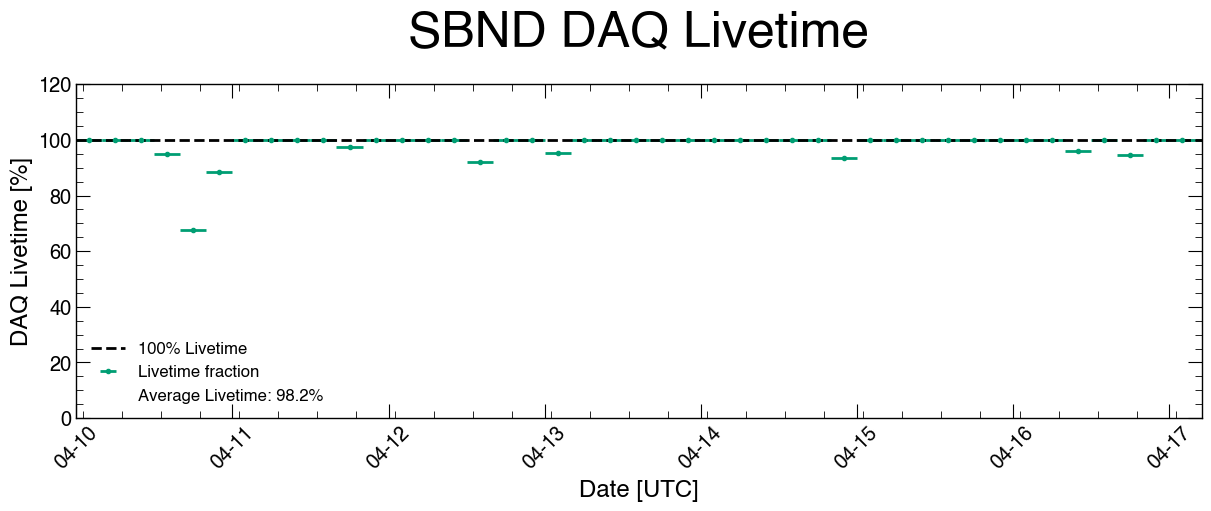

In [6]:
livetime_df = pd.read_csv(projectPath+'data_csv/sbnd_livetime_week.csv')

# convert to datetime
livetime_df['start'] = pd.to_datetime(livetime_df['start'])
livetime_df['end'] = pd.to_datetime(livetime_df['end'])

# Figure creation
figure = plt.figure(figsize=(12, 5))
ax = figure.add_subplot()

# Plot the livetime fraction
diff = livetime_df['end'] - livetime_df['start']
centers = livetime_df['start'] + diff / 2
ax.errorbar(centers,
            100*livetime_df['livetime_fraction'],
            xerr=diff / 2,
            fmt='o',
            label='Livetime fraction',
            markersize=3)
ax.set_xlabel('Date [UTC]')
ax.set_ylabel('DAQ Livetime [%]')

# Only show the x-axis label every day and rotate the labels
# Set major ticks to be every day
ax.xaxis.set_major_locator(DayLocator(interval=1))
ax.xaxis.set_major_formatter(DateFormatter('%m-%d'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='center')

# Set minor ticks to be every 6 hours
ax.xaxis.set_minor_locator(HourLocator(interval=6))
plt.setp(ax.xaxis.get_minorticklabels(), rotation=45, ha='center')

# Set axis limits
ax.set_xlim(plot_start, plot_end)
ax.set_ylim(0, 120)
ax.axhline(100, color='black', linestyle='--', label='100% Livetime')

# Add a legend, but add statistics showing the average livetime fraction
h, l = ax.get_legend_handles_labels()
avg_livetime = np.mean(livetime_df['livetime_fraction'])

# Add the average livetime to the legend, but with a "blank" handle
h.append(plt.Line2D([0], [0], color='white', lw=0))
l.append(f'Average Livetime: {avg_livetime:.1%}')
ax.legend(h, l)

_ = ax.set_title('SBND DAQ Livetime')

# Save the figure
figure.savefig(projectPath + 'plots/daq_weekly_livetime.png', dpi=1000, bbox_inches='tight')
figure.savefig(projectPath + 'plots/daq_weekly_livetime.pdf', dpi=1000, bbox_inches='tight')
figure.savefig(projectPath + 'plots/daq_weekly_livetime_light.png', dpi=50, bbox_inches='tight')

from PIL import Image
img = Image.open(projectPath + 'plots/daq_weekly_livetime.png')
img.save(projectPath + 'plots/daq_weekly_livetime_light2.png', format="PNG", optimize=True, compress_level=9)

## POT Collection Efficiency
This plots the POT collection efficiency, which represents the fraction of POT delivered by AD to the BNB that SBND was online and capable of taking physics-quality data for.

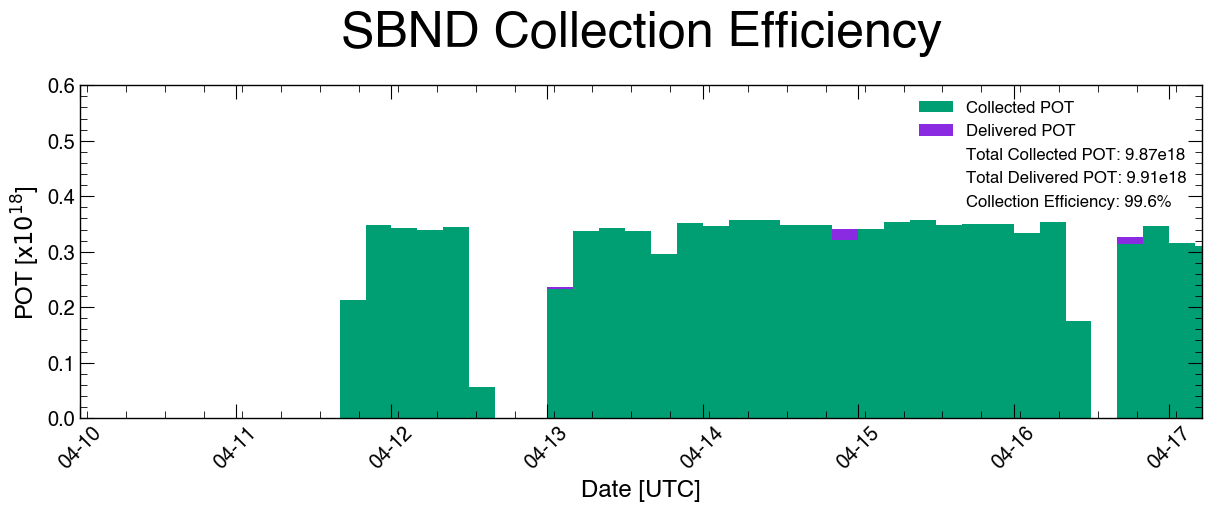

In [7]:
livetime_df = pd.read_csv(projectPath+'data_csv/sbnd_livetime_week.csv')

# convert to datetime
livetime_df['start'] = pd.to_datetime(livetime_df['start'])
livetime_df['end'] = pd.to_datetime(livetime_df['end'])
diff = livetime_df['end'] - livetime_df['start']

# Figure creation for POT delivered and collected
figure = plt.figure(figsize=(12, 5))
ax = figure.add_subplot()

# Stacked bar plot of the total POT delivered and collected.
ax.bar(centers, livetime_df['collected_pot']/1e6, width=diff, label='Collected POT', alpha=1, zorder=1, color='C0')
ax.bar(centers, livetime_df['delivered_pot']/1e6, width=diff, label='Delivered POT', alpha=1, zorder=0, color='blueviolet')
ax.set_xlabel('Date [UTC]')
ax.set_ylabel('POT [x$10^{18}$]')

# Only show the x-axis label every day and rotate the labels
# Set major ticks to be every day
ax.xaxis.set_major_locator(DayLocator(interval=1))
ax.xaxis.set_major_formatter(DateFormatter('%m-%d'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='center')

# Set minor ticks to be every 6 hours
ax.xaxis.set_minor_locator(HourLocator(interval=6))
plt.setp(ax.xaxis.get_minorticklabels(), rotation=45, ha='center')

# Set axis limits
ax.set_xlim(plot_start, plot_end)
ax.set_ylim(0, 0.60)

# Add a legend, but add statistics showing the total delivered POT,
# collected POT, and the collection efficiency
h, l = ax.get_legend_handles_labels()
total_delivered_pot = np.sum(livetime_df['delivered_pot'])
total_collected_pot = np.sum(livetime_df['collected_pot'])
collection_efficiency = total_collected_pot / total_delivered_pot

# Add the average livetime to the legend, but with a "blank" handle
h.append(plt.Line2D([0], [0], color='white', lw=0))
l.append(f'Total Collected POT: {total_collected_pot*1e12:.2e}'.replace('+', ''))
h.append(plt.Line2D([0], [0], color='white', lw=0))
l.append(f'Total Delivered POT: {total_delivered_pot*1e12:.2e}'.replace('+', ''))
h.append(plt.Line2D([0], [0], color='white', lw=0))
l.append(f'Collection Efficiency: {collection_efficiency:.1%}')
ax.legend(h, l)

# Title
_ = ax.set_title('SBND Collection Efficiency')


# Save the figure
figure.savefig(projectPath + 'plots/pot_weekly_collection_efficiency.png', dpi=1000, bbox_inches='tight')
figure.savefig(projectPath + 'plots/pot_weekly_collection_efficiency.pdf', dpi=1000, bbox_inches='tight')
figure.savefig(projectPath + 'plots/pot_weekly_collection_efficiency_light.png', dpi=50, bbox_inches='tight')

# Adding the week of data to the rest of Run 2
Run the code above for each week, then run this section of code to add it to the file of all Run 2 so far

In [8]:
#Run 2 file
livetime_run2_df = pd.read_csv(projectPath+'data_csv/sbnd_livetime_run2.csv', index_col=0)
#The week of data
livetime_week_df = pd.read_csv(projectPath+'data_csv/sbnd_livetime_week.csv', index_col=0)
#Combine them
livetime_df = pd.concat([livetime_run2_df, livetime_week_df], ignore_index=True)
#Remove the duplicated intervals
livetime_df  = livetime_df.drop_duplicates(
    subset=["start", "end"],  # your date columns
    keep="first"  # keeps existing, ignores new duplicates
)
livetime_df.to_csv(projectPath+"data_csv/sbnd_livetime_run2.csv", index=True)

# Run 2 Cumulative

Hit  17.5 at  2026-02-04 04:00:00+00:00  +  1.5257103640029794 hours 
	 17.489086233847374 17.517699177457438
Total Delivered POT: 265120021.57298595


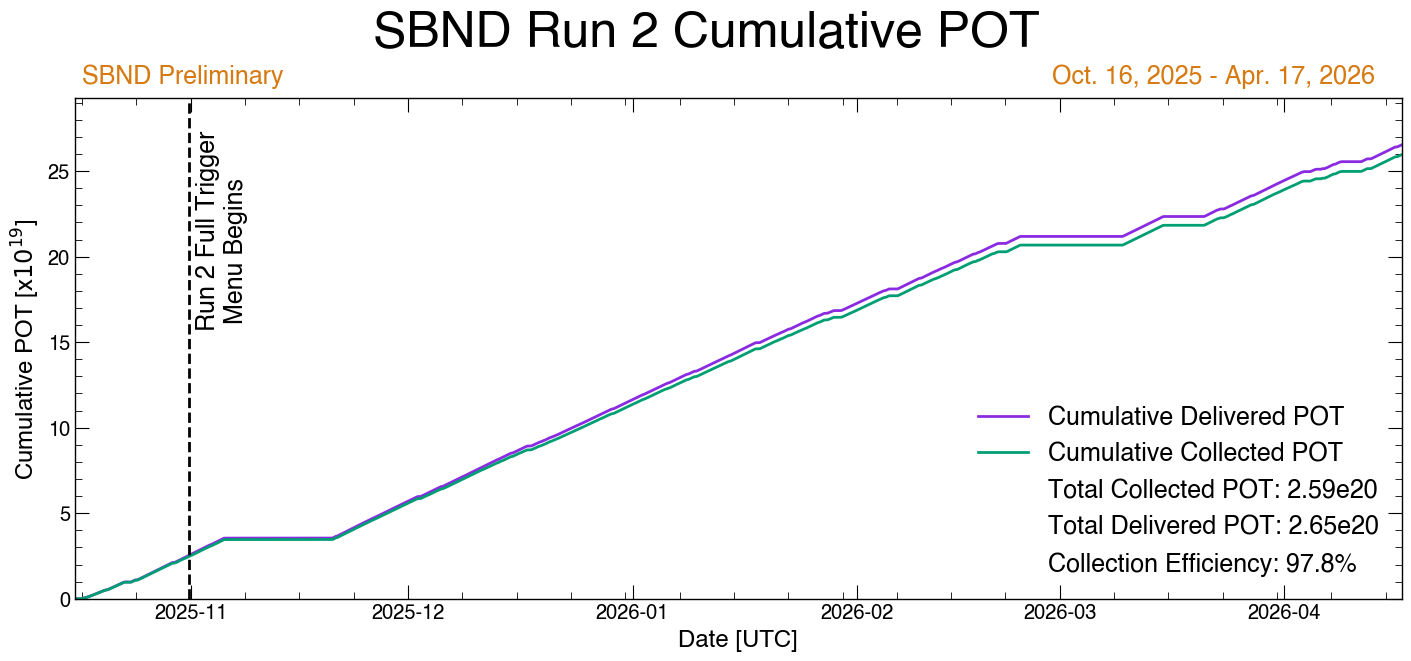

In [9]:
#Run 2 only
livetime_df = pd.read_csv(projectPath+'data_csv/sbnd_livetime_run2.csv')
startTime = datetime(2025, 10, 16, 0, 0, 0, tzinfo=timezone.utc)
date_label = f"{startTime.strftime('%b. %-d, %Y')} - {endTime.strftime('%b. %-d, %Y')}"

livetime_df['start'] = pd.to_datetime(livetime_df['start'])
livetime_df['end'] = pd.to_datetime(livetime_df['end'])

figure = plt.figure(figsize=(14, 6.5))
ax = figure.add_subplot()

# Center points for the x-axis
diff = livetime_df['end'] - livetime_df['start']
centers = livetime_df['start'] + diff / 2

# Print the times of hitting key values
pot_of_interest = 17.5
collected_pot_sofar = 0 #this is e19
for i, row in livetime_df.iterrows():
    if(collected_pot_sofar < pot_of_interest):
        collected_pot_sofar = collected_pot_sofar + row['collected_pot']/1e7
        if(collected_pot_sofar > pot_of_interest): print("Hit ", pot_of_interest, "at ", row['start'], " + ", (pot_of_interest-(collected_pot_sofar-row['collected_pot']/1e7))/(row['collected_pot']/1e7)*4, "hours \n\t", collected_pot_sofar-row['collected_pot']/1e7, collected_pot_sofar)


# Annotations
annotes = {'Run 2 Full Trigger \n Menu Begins': datetime(2025, 10, 31, 17, 19, 56, tzinfo=timezone.utc),}


# Each time point is a cumulative sum of the delivered / collected POT
ax.plot(centers, np.cumsum(livetime_df['delivered_pot'])/1e7, label='Cumulative Delivered POT', color='blueviolet')
ax.plot(centers, np.cumsum(livetime_df['collected_pot'])/1e7, label='Cumulative Collected POT', color='C0')

ax.set_xlabel('Date [UTC]')
ax.set_ylabel('Cumulative POT [x$10^{19}$]')
ax.set_xlim(startTime, endTime)
yMax = ax.get_ylim()[1]
ax.set_ylim(0, yMax*1.05)

# Add a legend, but add statistics showing the total delivered POT,
# collected POT, and the collection efficiency
mask = ((livetime_df['start'] >= startTime)
        & (livetime_df['end'] <= endTime))


h, l = ax.get_legend_handles_labels()
total_delivered_pot = np.sum(livetime_df['delivered_pot'][mask])
print(f'Total Delivered POT: {total_delivered_pot}')
total_collected_pot = np.sum(livetime_df['collected_pot'][mask])
collection_efficiency = total_collected_pot / total_delivered_pot

# Add the average livetime to the legend, but with a "blank" handle
h.append(plt.Line2D([0], [0], color='white', lw=0))
l.append(f'Total Collected POT: {total_collected_pot*1e12:.2e}'.replace('+', ''))
h.append(plt.Line2D([0], [0], color='white', lw=0))
l.append(f'Total Delivered POT: {total_delivered_pot*1e12:.2e}'.replace('+', ''))
h.append(plt.Line2D([0], [0], color='white', lw=0))
l.append(f'Collection Efficiency: {collection_efficiency:.1%}')
ax.legend(h, l, loc='lower right', fontsize=18)

date_padding = timedelta(days=1)
for label, date in annotes.items():
    ax.axvline(date, color='black', linestyle='--', lw=2)
    #ax.text(date+date_padding, 37.5-1.0, label, rotation=90, ha='left', va='top', fontsize=18,)
    ax.text(date+date_padding, 0.95, label, rotation=90, ha='left', va='top', fontsize=18,transform=ax.get_xaxis_transform())


vadj, hadj = 0.02, -0.02
label = 'SBND Preliminary'

yrange = ax.get_ylim()
usey = yrange[1] + 0.01*(yrange[1] - yrange[0]) + vadj*(yrange[1] - yrange[0])
xrange = ax.get_xlim()
usex = xrange[0] + 0.025*(xrange[1] - xrange[0]) + hadj*(xrange[1] - xrange[0])
ax.text(x=usex, y=usey, s=label, fontsize=18, color='#d67a11')


ax.text(x=xrange[1] + hadj*(xrange[1] - xrange[0]),
        y=usey, s=date_label, fontsize=18, color='#d67a11', ha='right')

logo = mpimg.imread(projectPath + 'include/sbnd_logo.jpeg')
im = OffsetImage(logo, zoom=0.5, alpha=0.2)

# create an AnnotationBbox at axes fraction (x=0.5,y=0.5) = the center
# you can move it to e.g. (0.9,0.1) for bottom-right, etc.
ab = AnnotationBbox(
    im,
    #(0.12, 0.7),                # x,y in axes fraction
    (0.5, 0.5),
    xycoords='axes fraction',
    frameon=False,             # no border
    pad=0                      # no extra padding
)
#ax.add_artist(ab)

figure.suptitle('SBND Run 2 Cumulative POT')
figure.savefig( projectPath + 'plots/livetime_pot_cumulative_run2.png', dpi=1000, bbox_inches='tight')
figure.savefig( projectPath + 'plots/livetime_pot_cumulative_run2.pdf', dpi=1000, bbox_inches='tight')
figure.savefig( projectPath + 'plots/livetime_pot_cumulative_run2_light.png', dpi=50, bbox_inches='tight')

# Run 1 + Run 2 Cumulative

Hit  52.5 at  2026-01-27 00:00:00+00:00  +  2.54560529924099 hours 
	 52.47836883400513 52.512358653245876
Total Delivered POT: 633420074.9177706


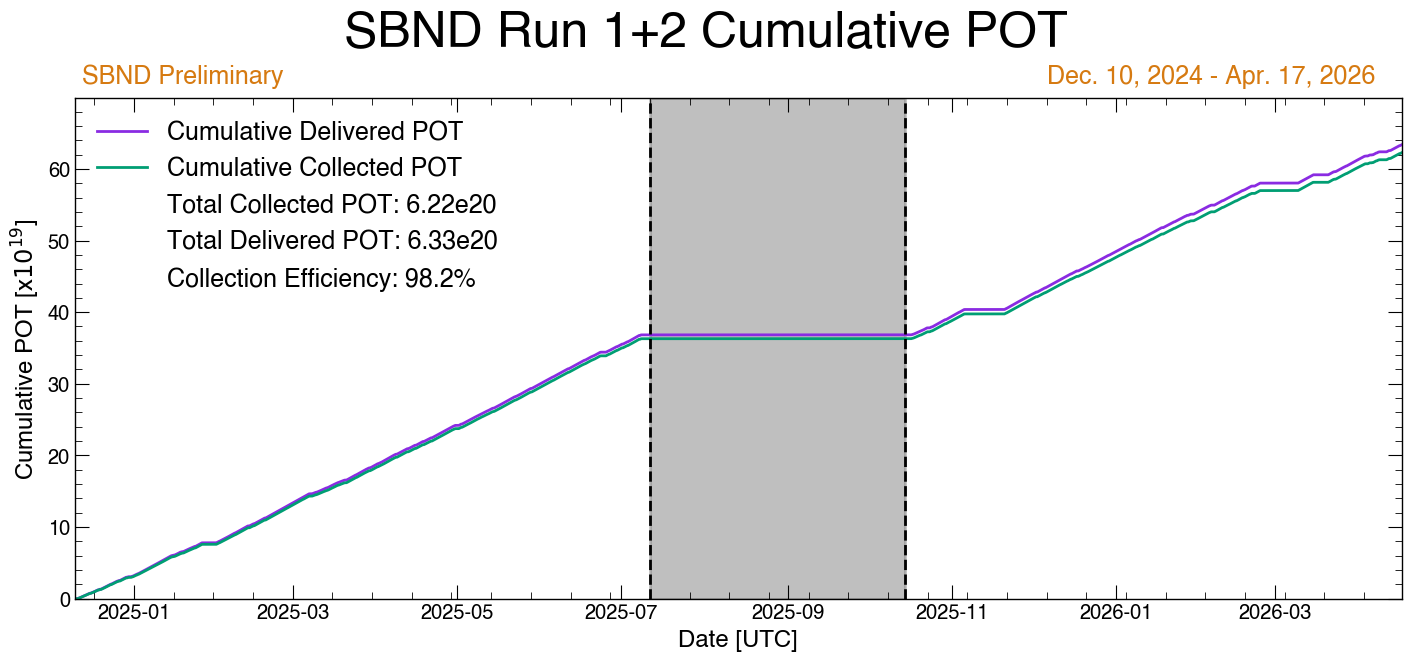

In [10]:
startTime = datetime(2024, 12, 10, 0, 0, 0, tzinfo=timezone.utc)
end_time = endTime
date_label = f"{startTime.strftime('%b. %-d, %Y')} - {end_time.strftime('%b. %-d, %Y')}"

#Run 1 file
livetime_run1_df = pd.read_csv(projectPath + 'data_csv/sbnd_livetime_run1_final.csv')
#Run 2 file
livetime_run2_df = pd.read_csv(projectPath + 'data_csv/sbnd_livetime_run2.csv')
#Combine them
livetime_df = pd.concat([livetime_run1_df, livetime_run2_df], ignore_index=True)

livetime_df['start'] = pd.to_datetime(livetime_df['start'])
livetime_df['end'] = pd.to_datetime(livetime_df['end'])

figure = plt.figure(figsize=(14, 6.5))
ax = figure.add_subplot()

# Center points for the x-axis
diff = livetime_df['end'] - livetime_df['start']
centers = livetime_df['start'] + diff / 2

# Annotations
annotes = {'End Run 1': datetime(2025, 7, 11, 17, 19, 56, tzinfo=timezone.utc),'Start Run 2': datetime(2025, 10, 14, 17, 19, 56, tzinfo=timezone.utc),}


# Print the times of hitting key values
pot_of_interest = 52.5
collected_pot_sofar = 0 #this is e19
for i, row in livetime_df.iterrows():
    if(collected_pot_sofar < pot_of_interest):
        collected_pot_sofar = collected_pot_sofar + row['collected_pot']/1e7
        if(collected_pot_sofar > pot_of_interest): print("Hit ", pot_of_interest, "at ", row['start'], " + ", (pot_of_interest-(collected_pot_sofar-row['collected_pot']/1e7))/(row['collected_pot']/1e7)*4, "hours \n\t", collected_pot_sofar-row['collected_pot']/1e7, collected_pot_sofar)



# Each time point is a cumulative sum of the delivered / collected POT
ax.plot(centers, np.cumsum(livetime_df['delivered_pot'])/1e7, label='Cumulative Delivered POT', color='blueviolet')
ax.plot(centers, np.cumsum(livetime_df['collected_pot'])/1e7, label='Cumulative Collected POT', color='C0')


addProjection = False
if(addProjection):
    # Add projections
    slopeCalcStart = datetime(2025, 10, 16, 0, 0, 0, tzinfo=ZoneInfo('America/Chicago'))
    slopeCalcEnd = endTime
    endTimeProj = datetime(2026, 6, 12, 0, 0, 0, tzinfo=ZoneInfo('America/Chicago'))

    maskCalc = ( (livetime_df['start'] >= slopeCalcStart) & (livetime_df['end'] <= slopeCalcEnd) )
    # mask out entries with collected POT <1000 
    maskCalc = maskCalc & (livetime_df['collected_pot'] > 1000)
    deliveredPOTs = livetime_df['delivered_pot'][maskCalc]
    collectedPOTs = livetime_df['collected_pot'][maskCalc]
    mean_collected_pot = np.mean(collectedPOTs)
    mean_delivered_pot = np.mean(deliveredPOTs)

    print(f"Mean collected POT in the slope calculation period:", mean_collected_pot)
    print(f"Mean delivered POT in the slope calculation period: ", mean_delivered_pot)

    # New dataframe for the projection, starting from the last point in the original dataframe
    last_date = livetime_df['end'].max()
    last_collected_pot = livetime_df['collected_pot'][livetime_df['end'] == last_date].values[0]/1e7
    last_delivered_pot = livetime_df['delivered_pot'][livetime_df['end'] == last_date].values[0]/1e7
    livetime_df_proj = livetime_df
    # Iteratively add rows to the projection dataframe until we reach the end time
    while livetime_df_proj['end'].iloc[-1] < endTimeProj:
        new_start = livetime_df_proj['end'].iloc[-1]
        new_end = new_start + timedelta(hours=4)
        new_collected_pot = mean_collected_pot
        new_delivered_pot = mean_delivered_pot
        #last_collected_pot = new_collected_pot
        #last_delivered_pot = new_delivered_pot
        new_row = pd.DataFrame({
            'start': [new_start],
            'end': [new_end],
            'collected_pot': [new_collected_pot],
            'delivered_pot': [new_delivered_pot],
        })
        livetime_df_proj = pd.concat([livetime_df_proj, new_row], ignore_index=True)


    # Plot the projection
    diffProj = livetime_df_proj['end'] - livetime_df_proj['start']
    centersProj =  livetime_df_proj['start'] + diffProj / 2
    ax.plot(centersProj, np.cumsum(livetime_df_proj['delivered_pot'])/1e7, label='Run 2 projection (delivered)', color='blueviolet', linestyle='--')
    ax.plot(centersProj, np.cumsum(livetime_df_proj['collected_pot'])/1e7, label='Run 2 projection (collected)', color='C0', linestyle='--')
    endTime = endTimeProj

ax.set_xlabel('Date [UTC]')
ax.set_ylabel('Cumulative POT [x$10^{19}$]')
ax.set_xlim(startTime, endTime)
yMax = ax.get_ylim()[1]
ax.set_ylim(0, yMax*1.05)

# Add a legend, but add statistics showing the total delivered POT,
# collected POT, and the collection efficiency
mask = (
        (livetime_df['start'] >= startTime)
        & (livetime_df['end'] <= endTime)
        )

h, l = ax.get_legend_handles_labels()
total_delivered_pot = np.sum(livetime_df['delivered_pot'][mask])
print(f'Total Delivered POT: {total_delivered_pot}')
total_collected_pot = np.sum(livetime_df['collected_pot'][mask])
collection_efficiency = total_collected_pot / total_delivered_pot

# Add the average livetime to the legend, but with a "blank" handle
h.append(plt.Line2D([0], [0], color='white', lw=0))
l.append(f'Total Collected POT: {total_collected_pot*1e12:.2e}'.replace('+', ''))
h.append(plt.Line2D([0], [0], color='white', lw=0))
l.append(f'Total Delivered POT: {total_delivered_pot*1e12:.2e}'.replace('+', ''))
h.append(plt.Line2D([0], [0], color='white', lw=0))
l.append(f'Collection Efficiency: {collection_efficiency:.1%}')
ax.legend(h, l, loc='upper left', fontsize=18)



date_padding = timedelta(days=1)
for label, date in annotes.items():
    ax.axvline(date, color='black', linestyle='--', lw=2)
    #ax.text(date+date_padding, 37.5-1.0, label, rotation=90, ha='left', va='top', fontsize=18,)
#    ax.text(date+date_padding, 0.95, label, rotation=90, ha='left', va='top', fontsize=18,transform=ax.get_xaxis_transform())

ax.axvspan(annotes["End Run 1"], annotes["Start Run 2"], color = "gray", alpha = 0.5)


vadj, hadj = 0.02, -0.02
label = 'SBND Preliminary'

yrange = ax.get_ylim()
usey = yrange[1] + 0.01*(yrange[1] - yrange[0]) + vadj*(yrange[1] - yrange[0])
xrange = ax.get_xlim()
usex = xrange[0] + 0.025*(xrange[1] - xrange[0]) + hadj*(xrange[1] - xrange[0])
ax.text(x=usex, y=usey, s=label, fontsize=18, color='#d67a11')

# Opposite the previous label, place the dates
ax.text(x=xrange[1] + hadj*(xrange[1] - xrange[0]),
        y=usey, s=date_label, fontsize=18, color='#d67a11', ha='right')

logo = mpimg.imread(projectPath + 'include/sbnd_logo.jpeg')
im = OffsetImage(logo, zoom=0.5, alpha=0.2)

# create an AnnotationBbox at axes fraction (x=0.5,y=0.5) = the center
# you can move it to e.g. (0.9,0.1) for bottom-right, etc.
ab = AnnotationBbox(
    im,
    #(0.12, 0.7),                # x,y in axes fraction
    (0.5, 0.5),
    xycoords='axes fraction',
    frameon=False,             # no border
    pad=0                      # no extra padding
)
#ax.add_artist(ab)



figure.suptitle('SBND Run 1+2 Cumulative POT')
figure.savefig(projectPath + 'plots/livetime_pot_cumulative_run1+2.png', dpi=1000, bbox_inches='tight')
figure.savefig(projectPath + 'plots/livetime_pot_cumulative_run1+2.pdf', dpi=1000, bbox_inches='tight')
figure.savefig(projectPath + 'plots/livetime_pot_cumulative_run1+2_light.png', dpi=50, bbox_inches='tight')

# Run Length and Transition Time
Histograms of the length of the run and how long it took to transition between them

473


(0.0, 400.0)

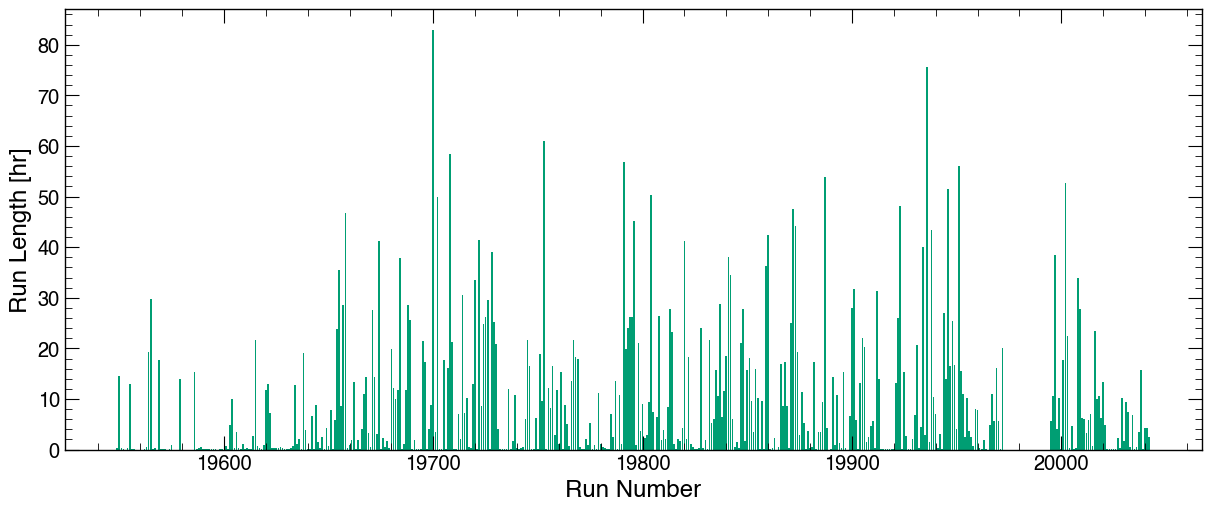

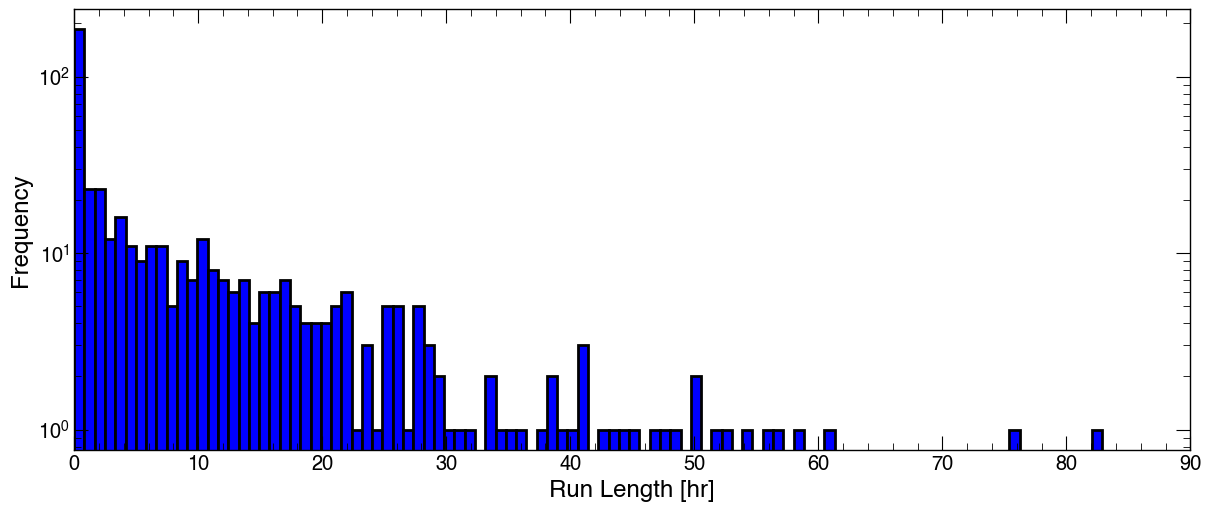

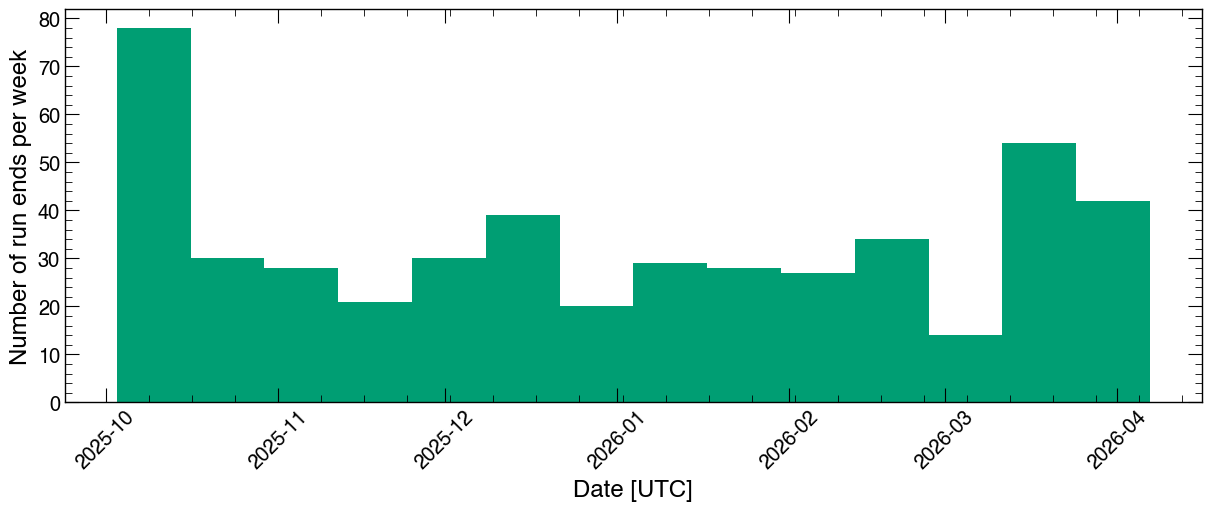

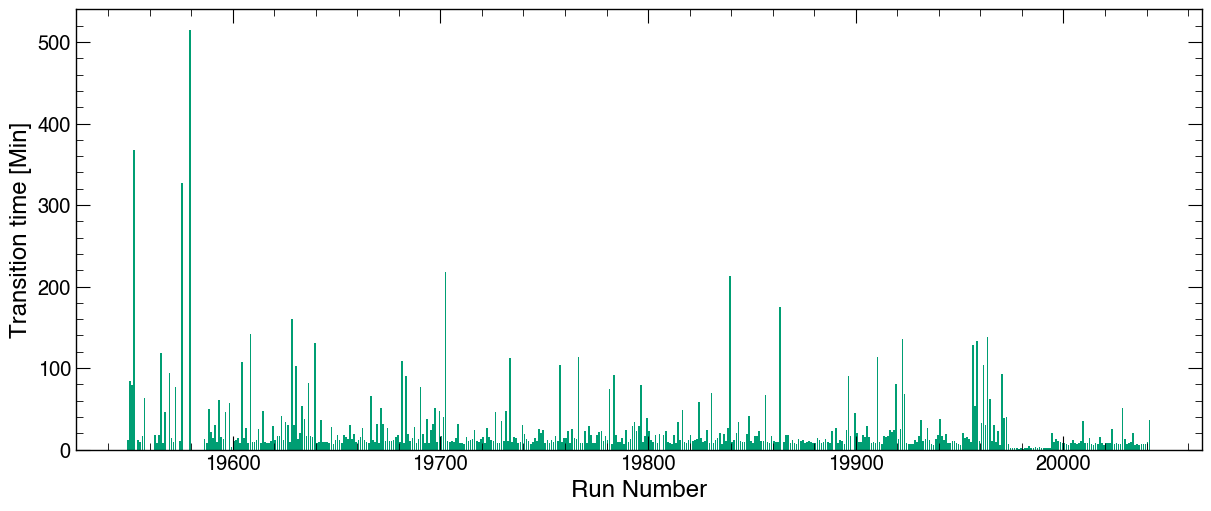

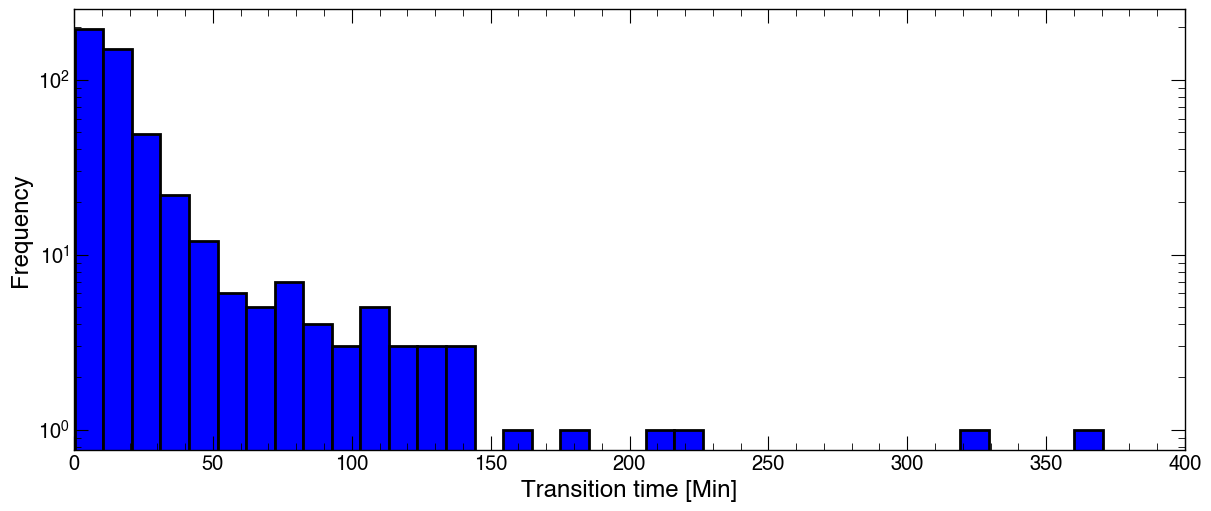

In [58]:
# Putting this here again so that this portion of the code can run without the internet
# Read the run start times from `starts.txt`
with open('data/starts_run2.txt', 'r') as f:
    lines = f.readlines()
    starts = [datetime.strptime(line.strip(), '%Y-%m-%d %H:%M:%S').replace(tzinfo=timezone.utc) for line in lines]

# Read the run end times from `ends.txt`
with open('data/ends_run2.txt', 'r') as f:
    lines = f.readlines()
    ends = [datetime.strptime(line.strip(), '%Y-%m-%d %H:%M:%S').replace(tzinfo=timezone.utc) if line != 'now\n' else datetime.now(timezone.utc) for line in lines]

runNumbers = []
# Read the run numbers from `runNums.txt`
with open('data/runNums_run2.txt', 'r') as f:
    runNumbers = f.readlines()
#    runs = [lines for line in lines]

run_indeces = []
run_lengths = []
run_number = []
transition_indeces = []
transition_time = []
transition_number = []
# go through and calculate the run lengths
for i in range(len(starts)):
    #print("at index", i, "the start time is", starts[i], "and the end time is", ends[i])
#    print("run length is ", ends[i]-starts[i], "in minutes its", ((ends[i]-starts[i]).total_seconds())/(60*60))
#    if(i!=len(starts)-1): print("transition took ", (starts[i+1]-ends[i]))
    if(i!=len(starts)-1):    
        run_indeces.append(i)
        run_number.append(float(runNumbers[i]))
        run_lengths.append(((ends[i]-starts[i]).total_seconds())/(60*60))
        if(i!=len(starts)-2):
            transition_indeces.append(i)
            transition_number.append(float(runNumbers[i])+0.5)
            transition_time.append((starts[i+1]-ends[i]).total_seconds()/(60))

# Figure creation
figure = plt.figure(figsize=(12, 5))
ax = figure.add_subplot()

print(len(run_lengths))

ax.bar(run_number, run_lengths, alpha=1, zorder=1, color='C0')
ax.set_xlabel('Run Number')
#plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='center')
ax.set_ylabel('Run Length [hr]')

# Histogram of frequency
figure = plt.figure(figsize=(12, 5))
ax2 = figure.add_subplot()
ax2.hist(run_lengths, bins=100, color='blue', edgecolor='black')
ax2.set_xlabel("Run Length [hr]")
ax2.set_ylabel("Frequency")
ax2.set_yscale('log')
ax2.set_xlim(0, 90)


# Histogram of the number of run ends for each day
figure = plt.figure(figsize=(12, 5))
ax3 = figure.add_subplot()
ax3.hist(ends, bins=14)
ax3.set_xlabel('Date [UTC]')
ax3.set_ylabel('Number of run ends per week')
plt.setp(ax3.xaxis.get_majorticklabels(), rotation=45, ha='center')

# bar graph of transition time vs run number
figure = plt.figure(figsize=(12, 5))
ax = figure.add_subplot()
ax.bar(transition_number, transition_time, alpha=1, zorder=1, color='C0')
ax.set_xlabel('Run Number')
ax.set_ylabel('Transition time [Min]')

# Histogram of frequency
figure = plt.figure(figsize=(12, 5))
ax2 = figure.add_subplot()
ax2.hist(transition_time, bins=50, color='blue', edgecolor='black')
ax2.set_xlabel("Transition time [Min]")
ax2.set_ylabel("Frequency")
ax2.set_yscale('log')
ax2.set_xlim(0,400)
